In [1]:
import pandas as pd
df = pd.read_csv("creditcard.csv")
print(df.shape)
df.info()
print(df["Class"].value_counts(normalize=True))  # see how rare fraud is

(284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     

Load and inspect

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df["Time_scaled"] = scaler.fit_transform(df[["Time"]])
df = df.drop(["Amount", "Time"], axis=1)

Clean / prepare

In [ ]:
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df["Time_scaled"] = scaler.fit_transform(df[["Time"]])
df = df.drop(["Amount", "Time"], axis=1)

EDA

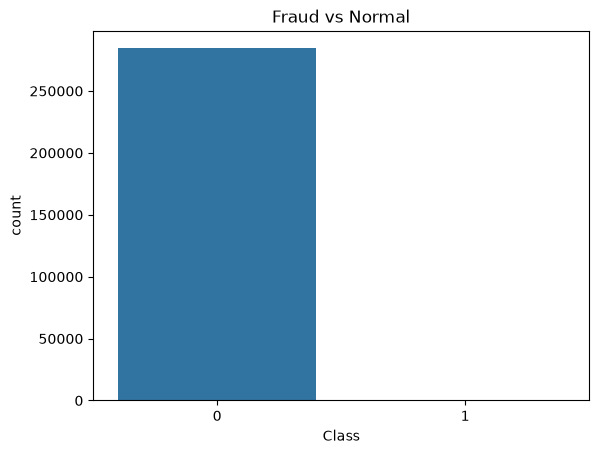

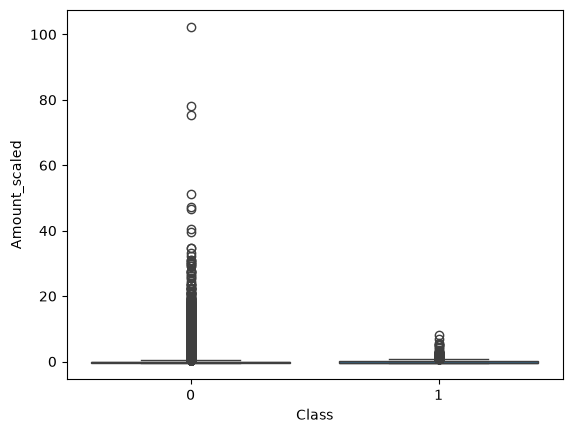

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt
sns.countplot(x="Class", data=df); plt.title("Fraud vs Normal"); plt.show()
sns.boxplot(x="Class", y="Amount_scaled", data=df); plt.show()

Split, then balance (train data only)

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
X = df.drop("Class", axis=1)
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)
print(y_train_sm.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


Train TWO kinds of models (this is the new part)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

clf_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
}
for name, m in clf_models.items():
    m.fit(X_train_sm, y_train_sm)

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.0017, random_state=42)  # ~fraud rate
iso.fit(X_train)  # note: NOT the SMOTE-balanced data
iso_preds = iso.predict(X_test)
iso_preds = [1 if p == -1 else 0 for p in iso_preds]  # -1 means anomaly -> fraud

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.0017, random_state=42)  # ~fraud rate
iso.fit(X_train)  # note: NOT the SMOTE-balanced data
iso_preds = iso.predict(X_test)
iso_preds = [1 if p == -1 else 0 for p in iso_preds]  # -1 means anomaly -> fraud

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

for name, m in clf_models.items():
    preds = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    print(f"\n=== {name} ===")
    print(classification_report(y_test, preds))
    print("AUC-ROC:", roc_auc_score(y_test, proba))

print("\n=== Isolation Forest ===")
print(classification_report(y_test, iso_preds))


=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9688299436966684

=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.68      0.86      0.76        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.974522814190392

=== Isolation Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.31      0.33      0.32        98

    accuracy                           1.00     56962
   macr

In [ ]:
import joblib
joblib.dump(clf_models["XGBoost"], "fraud_model.pkl")

['fraud_model.pkl']

In [ ]:
print(df.columns.tolist())
print(df[["Amount_scaled", "Time_scaled"]].head())

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_scaled', 'Time_scaled']
   Amount_scaled  Time_scaled
0       0.244964    -1.996583
1      -0.342475    -1.996583
2       1.160686    -1.996562
3       0.140534    -1.996562
4      -0.073403    -1.996541
